# Evaluation Notebook 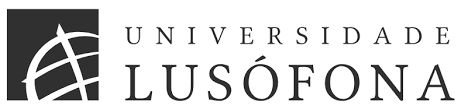 
## <font color='seablue'>**Benchmarking LLMs on Project Management**</font>
### <font color='black'>**Assessing Results**</font>
#### <font color='grey'> *João Caldeira @ 2025*</font>
This Notebook assesses multiple results of LLMs in the context of Project Management.
<hr>

# Setup

In [33]:
#!pip install matplotlib
#!pip install seaborn 
#!pip install scipy
#!pip install krippendorff
#!pip install sklearn
#!pip install plotly
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
from scipy.stats import norm
from scipy import stats
from scipy.stats import rankdata
import krippendorff
from sklearn.metrics import cohen_kappa_score

In [34]:
# Plot dataframes side by side to avoid scrolling
from IPython.display import display, HTML
def plot_dataframes_side_by_side( dfs:list, captions:list, tablespacing=5 ):
    """Display tables side by side to save vertical space
    Input:
        dfs: list of pandas.DataFrame
        captions: list of table captions
    """
    output = ""
    for (caption, df) in zip(captions, dfs):
        output += df.style.set_table_attributes("style='display:inline'").set_caption(caption)._repr_html_()
        output += tablespacing * "\xa0"
    display(HTML(output))

In [35]:
def plot_box_by_prefix( dataset, id_vars=["question"]):
    
    # --- Melt data to long format ---
    value_cols = [c for c in dataset.columns if '_' in c]  # columns with '_v' pattern
    df_long = dataset.melt(
        id_vars=id_vars,
        value_vars=value_cols,
        var_name="Rater",
        value_name="Rating"
    )

    # --- Extract prefix before underscore ---
    df_long["Group"] = df_long["Rater"].str.split("_").str[0]
    df_long.drop(columns=["Rater"], inplace=True)

    # --- Create base box plot ---
    fig = px.box(
        df_long,
        x="Group",
        y="Rating",
        color="Group",
        points=False,  # remove data points
        title="Distribution of Ratings per Judge",
        template="plotly_white"
    )
    fig.update_traces(boxmean=True)

    # --- Compute group statistics ---
    group_stats = df_long.groupby("Group")["Rating"].agg(["mean", "median"]).reset_index()

    # --- Add mean and median annotations ---
    for i, row in group_stats.iterrows():
        # Mean label (above box)
        fig.add_trace(go.Scatter(
            x=[row["Group"]],
            y=[row["mean"]],
            mode="text",
            text=[f"Mean: {row['mean']:.2f}"],
            textposition="top center",
            showlegend=False
        ))
        # Median label (inside box)
        fig.add_trace(go.Scatter(
            x=[row["Group"]],
            y=[row["median"]],
            mode="text",
            text=[f"Med: {row['median']:.2f}"],
            textposition="middle center",
            showlegend=False
        ))

    # --- Layout polish ---
    fig.update_layout(
        xaxis_title="Judges",
        yaxis_title="Rating",
        showlegend=False,
        margin=dict(t=60, b=60)
    )

    fig.show()



In [36]:
import pandas as pd
from statistics import mode

def aggregate_groups( df, agg="mode"):
    """
    Aggregate AA, NA, and LLMx columns considering discrete ordinal values.
    Options for agg: "median", "mode", "sum"
    """
    aa_cols = [c for c in df.columns if c.startswith("AA_")]
    na_cols = [c for c in df.columns if c.startswith("NA_")]
    llm1_cols = [c for c in df.columns if c.startswith("LLM1_")]
    llm2_cols = [c for c in df.columns if c.startswith("LLM2_")]

    agg_df = df.copy()

    if agg == "median":
        agg_df["AA"] = df[aa_cols].median(axis=1)
        agg_df["NA"] = df[na_cols].median(axis=1)
        agg_df["LLM1"] = df[llm1_cols].median(axis=1)
        agg_df["LLM2"] = df[llm2_cols].median(axis=1)

    elif agg == "mode":
        agg_df["AA"] = df[aa_cols].apply(lambda row: mode(row), axis=1)
        agg_df["NA"] = df[na_cols].apply(lambda row: mode(row), axis=1)
        agg_df["LLM1"] = df[llm1_cols].apply(lambda row: mode(row), axis=1)
        agg_df["LLM2"] = df[llm2_cols].apply(lambda row: mode(row), axis=1)

    elif agg == "sum":
        agg_df["AA"] = df[aa_cols].sum(axis=1)
        agg_df["NA"] = df[na_cols].sum(axis=1)
        agg_df["LLM1"] = df[llm1_cols].sum(axis=1)
        agg_df["LLM2"] = df[llm2_cols].sum(axis=1)

    else:
        raise ValueError("agg must be 'median', 'mode', or 'sum'")

    return agg_df[["model","project","question","AA","NA","LLM1","LLM2"]]


In [37]:
def compute_kendall_w(df_subset):
    """Compute Kendall's W for ordinal rankings. Ensures 2D array input."""
    data = np.atleast_2d(df_subset.values)  # ensure 2D
    if data.shape[0] == 1 and data.shape[1] == 1:
        return np.nan  # not enough data to compute concordance

    # If columns < 2 (i.e., only one judge), return NaN
    if data.shape[1] < 2:
        return np.nan

    n_items, n_judges = data.shape
    ranks = np.array([rankdata(col) for col in data.T]).T
    sum_ranks = np.sum(ranks, axis=1)
    S = np.sum((sum_ranks - np.mean(sum_ranks))**2)
    W = 12 * S / (n_judges**2 * (n_items**3 - n_items))
    return W

In [38]:
def safe_cohen_kappa(y_true, y_pred, weights="quadratic"):
    """
    Compute Cohen's kappa safely.
    Returns 1.0 for identical constant ratings, np.nan for invalid inputs.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    combined = np.concatenate([y_true, y_pred])
    
    # Case 1: all same rating across both raters
    if len(np.unique(combined)) <= 1:
        return np.nan  # perfect agreement
    
    try:
        return cohen_kappa_score(y_true, y_pred, weights=weights)
    except Exception:
        return np.nan

In [39]:
def safe_krippendorff_alpha(data, level_of_measurement="ordinal", domain=None):
    """
    Computes Krippendorff's alpha safely, returning NaN when constant ratings occur.
    """
    # Flatten and remove missing values
    valid = data[~np.isnan(data)]
    unique_vals = np.unique(valid)

    if len(unique_vals) <= 1:
        # All judges gave same value — alpha undefined but perfect agreement
        return 1.0 # or return 1.0 if you prefer to treat as "perfect"
    else:
        return krippendorff.alpha(
            data,
            level_of_measurement=level_of_measurement,
            value_domain=domain
        )

In [40]:
def bootstrap_ci(series, n_boot=1000, confidence=0.95):
    boot_means = []
    for _ in range(n_boot):
        sample = series.sample(len(series), replace=True)
        boot_means.append(sample.mean())
    lower = np.percentile(boot_means, (1-confidence)/2*100)
    upper = np.percentile(boot_means, (1+confidence)/2*100)
    return lower, series.mean(), upper

In [41]:
def concordance_computation( dataset, mode = "question", columns_to_exclude = [], ndigits=3 ):
    evaluation_mode = mode # "question", "model", "project"
    records_q_all = []
    df = pd.DataFrame( dataset.dropna() )
    judges = dataset.drop( columns=columns_to_exclude).columns.to_list() # ["AA", "NA", "LLMx"]
    n_judges = len(judges)
    for q in sorted(df[evaluation_mode].unique()):
        #print(f"Processing {evaluation_mode}: {q}")
        df_q = df[df[evaluation_mode] == q]

        group_all = df_q[judges]
        
        median_scores = group_all.median()
        mode_scores = group_all.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

        if n_judges > 2:
            kendall = compute_kendall_w(group_all)
            alpha = safe_krippendorff_alpha(group_all.T.to_numpy(), level_of_measurement='ordinal')
            #alpha = safe_krippendorff_alpha(group_all)
            record = {"Id": q, "Kendall_W": round(kendall, ndigits), "Krippendorff_alpha": round(alpha, ndigits)}
        else:
            #if (q == 7): 
            #print(group_all)
            #    print(group_all.to_numpy())

            cohen = safe_cohen_kappa( group_all[judges[0]].round().astype(int), group_all[judges[1]].round().astype(int), weights="quadratic" )
            kendall = compute_kendall_w(group_all)
            spearman = group_all.corr('spearman').round(3)
            #print(group_all.T.to_numpy())
            alpha = safe_krippendorff_alpha(group_all.T.to_numpy(), level_of_measurement='ordinal')
            record = {"Id": q, "Cohen_kappa": round(cohen, ndigits), "Kendall_W": round(kendall, ndigits), "Spearman": round(spearman.loc[judges[0], judges[1]], ndigits), "Krippendorff_alpha": round(alpha, ndigits)}
            
        for col in df_q[judges].columns:
            record[f"{col}_median"] = median_scores[col]
            record[f"{col}_mode"] = mode_scores[col]
            
        records_q_all.append(record)
    return pd.DataFrame(records_q_all).round(ndigits)
        

In [42]:
# Sample data
def plot_metrics( dataset, njudges=2, filename="plot.png" ):
                            
    df = dataset #pd.DataFrame(data)

    # --- Reliability metrics chart ---
    fig_metrics = go.Figure()

    if (njudges < 3 ):
        metrics = ["Cohen_kappa", "Kendall_W", "Spearman", "Krippendorff_alpha"]
    else:
        metrics = ["Kendall_W", "Krippendorff_alpha"]

    for metric in metrics:
        fig_metrics.add_trace(go.Scatter(
            x=df["Id"],
            y=df[metric],
            #mode="lines+markers",
            
            mode="lines+markers+text",   # text will show labels
            #text=[f"{v:.2f}" for v in df[metric]],  # format labels
            textposition="top center",
            
            
            name=metric
        ))

    fig_metrics.update_layout(
        title="Inter-Rater Agreement Metrics per Id",
        xaxis_title="Id",
        yaxis_title="Metric Value",
        yaxis=dict(range=[-1,1]),  # all metrics are in [-1,1] or similar
        legend_title="Metrics",
        template="plotly_white"
    )

    # Force all x-axis ticks to show
    fig_metrics.update_xaxes(
        tickmode='array',
        tickvals=df["Id"],      # explicitly set ticks
        ticktext=[str(i) for i in df["Id"]]  # optional formatting
    )

    fig_metrics.show()

    # --- Optional: Median comparison chart ---
    fig_medians = go.Figure()

    median_cols = metrics # ["NA_median", "LLM1_median"]
    for col in median_cols:
        fig_medians.add_trace(go.Bar(
            x=df["Id"],
            y=df[col],
            name=col,
            text=[f"{v:.2f}" for v in df[col]],  # add labels
        ))

    fig_medians.update_layout(
        title="Median Ratings Comparison per Id",
        xaxis_title="Id",
        yaxis_title="Median Rating",
        barmode="group",
        template="plotly_white"
    )

    # Force all x-axis ticks
    fig_medians.update_xaxes(
        tickmode='array',
        tickvals=df["Id"],
        ticktext=[str(i) for i in df["Id"]]
    )


    fig_medians.show()
    #fig_medians.write_image(filename,engine="kaleido")


In [43]:
results = pd.read_excel('RC-New2.xlsx', index_col='key')
results = results[['model','project','question','AA_v1', 'AA_v2', 'AA_v3', 'AA_v4', 'AA_v5', 'NA_v1', 'NA_v2', 'NA_v3', 'NA_v4', 'NA_v5', 'LLM1_v1', 'LLM1_v2', 'LLM1_v3', 'LLM1_v4', 'LLM1_v5', 'LLM2_v1', 'LLM2_v2', 'LLM2_v3', 'LLM2_v4', 'LLM2_v5' ]]
results.sort_values(by=['key'], inplace=True)
columns_to_drop = ['model','project','question']

In [44]:
results

,model,project,question,AA_v1,AA_v2,AA_v3,AA_v4,AA_v5,NA_v1,NA_v2,...,LLM1_v1,LLM1_v2,LLM1_v3,LLM1_v4,LLM1_v5,LLM2_v1,LLM2_v2,LLM2_v3,LLM2_v4,LLM2_v5
key,,,,,,,,,,,,,,,,,,,,,
deepseek-r1_US285851_Q28,deepseek-r1,US285851,4,0,0,NaN,NaN,NaN,1,1,...,3,3,NaN,NaN,NaN,3,2,NaN,NaN,NaN
deepseek-r1_US285851_Q29,deepseek-r1,US285851,5,0,1,NaN,NaN,NaN,1,1,...,2,2,NaN,NaN,NaN,1,3,NaN,NaN,NaN
deepseek-r1_US285851_Q30,deepseek-r1,US285851,2,0,0,NaN,NaN,NaN,0,1,...,3,3,NaN,NaN,NaN,3,2,NaN,NaN,NaN
deepseek-r1_US285851_Q31,deepseek-r1,US285851,6,1,2,NaN,NaN,NaN,1,2,...,2,2,NaN,NaN,NaN,2,3,NaN,NaN,NaN
deepseek-r1_US285851_Q32,deepseek-r1,US285851,1,3,0,NaN,NaN,NaN,2,0,...,2,2,NaN,NaN,NaN,2,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
qwen3_US37581_Q23,qwen3,US37581,8,1,2,1.0,3.0,3.0,2,2,...,3,3,3.0,3.0,3.0,3,3,3.0,3.0,3.0
qwen3_US37581_Q24,qwen3,US37581,3,1,0,0.0,0.0,0.0,1,1,...,3,3,3.0,3.0,3.0,3,3,3.0,3.0,3.0
qwen3_US37581_Q25,qwen3,US37581,10,2,3,3.0,2.0,2.0,2,2,...,3,3,3.0,3.0,3.0,3,3,3.0,3.0,3.0


In [45]:
plot_box_by_prefix( results.drop( columns=['project','model'] ), id_vars=["question"] )


In [46]:
corr = results.drop(columns=columns_to_drop).corr('spearman').round(3)
corr

,AA_v1,AA_v2,AA_v3,AA_v4,AA_v5,NA_v1,NA_v2,NA_v3,NA_v4,NA_v5,LLM1_v1,LLM1_v2,LLM1_v3,LLM1_v4,LLM1_v5,LLM2_v1,LLM2_v2,LLM2_v3,LLM2_v4,LLM2_v5
AA_v1,1.000,0.320,0.430,0.442,0.351,0.848,0.364,0.502,0.501,0.455,0.101,0.101,0.107,0.107,0.107,0.115,0.062,-0.039,0.061,-0.061
AA_v2,0.320,1.000,0.597,0.720,0.675,0.264,0.672,0.603,0.615,0.610,0.093,0.093,0.120,0.120,0.120,0.135,0.127,0.116,0.112,0.122
AA_v3,0.430,0.597,1.000,0.669,0.651,0.428,0.613,0.759,0.759,0.681,0.157,0.157,0.269,0.269,0.269,0.243,0.163,0.216,0.246,0.088
AA_v4,0.442,0.720,0.669,1.000,0.777,0.388,0.616,0.660,0.752,0.614,0.240,0.240,0.222,0.222,0.222,0.281,0.118,0.175,0.217,0.184
AA_v5,0.351,0.675,0.651,0.777,1.000,0.330,0.634,0.638,0.710,0.655,0.209,0.209,0.198,0.198,0.198,0.251,0.099,0.179,0.192,0.214
NA_v1,0.848,0.264,0.428,0.388,0.330,1.000,0.390,0.529,0.501,0.442,0.199,0.199,0.175,0.175,0.175,0.202,0.159,0.046,0.126,-0.029
NA_v2,0.364,0.672,0.613,0.616,0.634,0.390,1.000,0.844,0.746,0.674,0.112,0.112,0.184,0.184,0.184,0.183,0.117,0.107,0.175,0.124
NA_v3,0.502,0.603,0.759,0.660,0.638,0.529,0.844,1.000,0.892,0.757,0.140,0.140,0.260,0.260,0.260,0.240,0.109,0.189,0.247,0.143
NA_v4,0.501,0.615,0.759,0.752,0.710,0.501,0.746,0.892,1.000,0.795,0.260,0.260,0.328,0.328,0.328,0.292,0.176,0.190,0.269,0.223
NA_v5,0.455,0.610,0.681,0.614,0.655,0.442,0.674,0.757,0.795,1.000,0.225,0.225,0.342,0.342,0.342,0.306,0.184,0.239,0.266,0.184


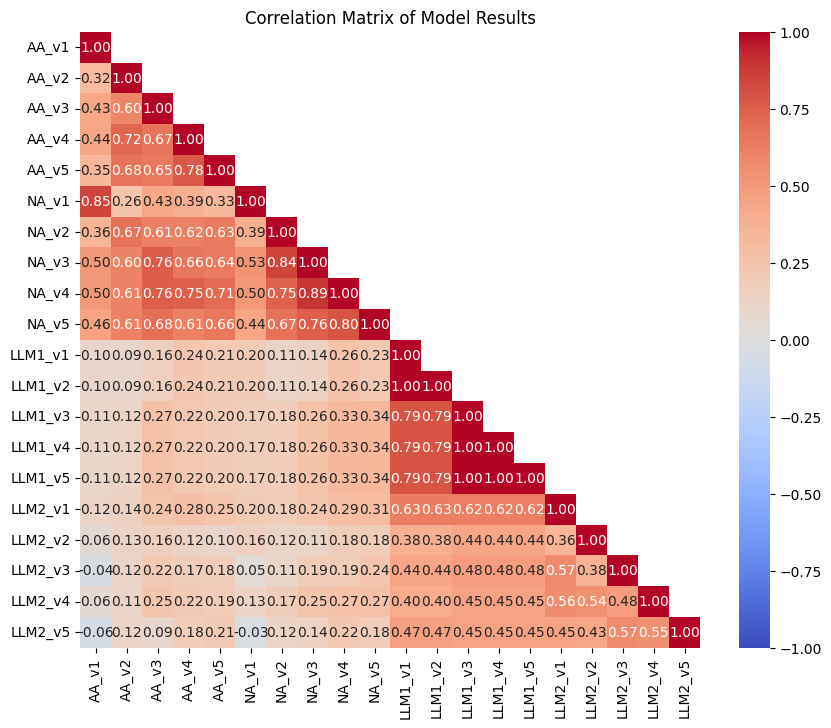

In [47]:
# Generate a heatmap

# Create a mask for the diagonal
#mask = np.eye(corr.shape[0], dtype=bool)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # lower triangle is True, upper is False

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, mask=mask)
plt.title('Correlation Matrix of Model Results')
plt.savefig("model_results_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show() 

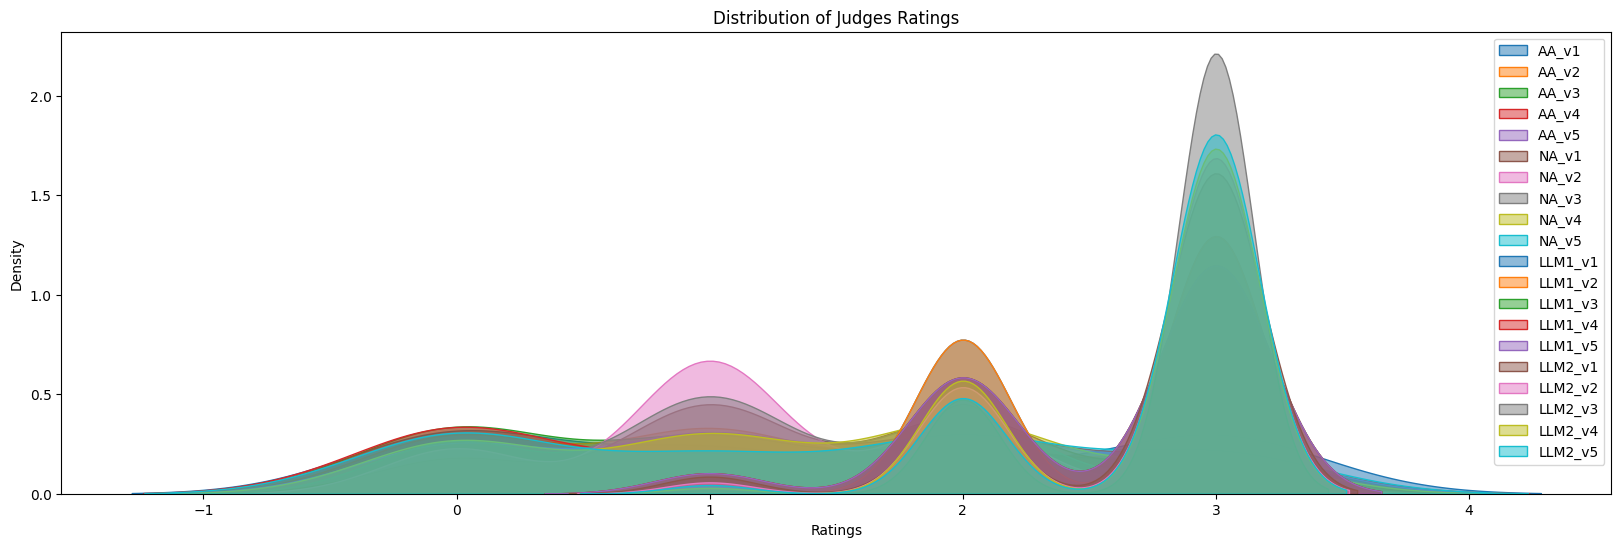

In [48]:
# Plot the distribution of results for each model
plt.figure(figsize=(20, 6))
for column in results.drop(columns = columns_to_drop).columns:
    sns.kdeplot(results[column], label=column, fill=True, alpha=0.5)
plt.title('Distribution of Judges Ratings')
plt.xlabel('Ratings')
plt.ylabel('Density')
plt.legend()
plt.savefig("multiple_evaluations_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

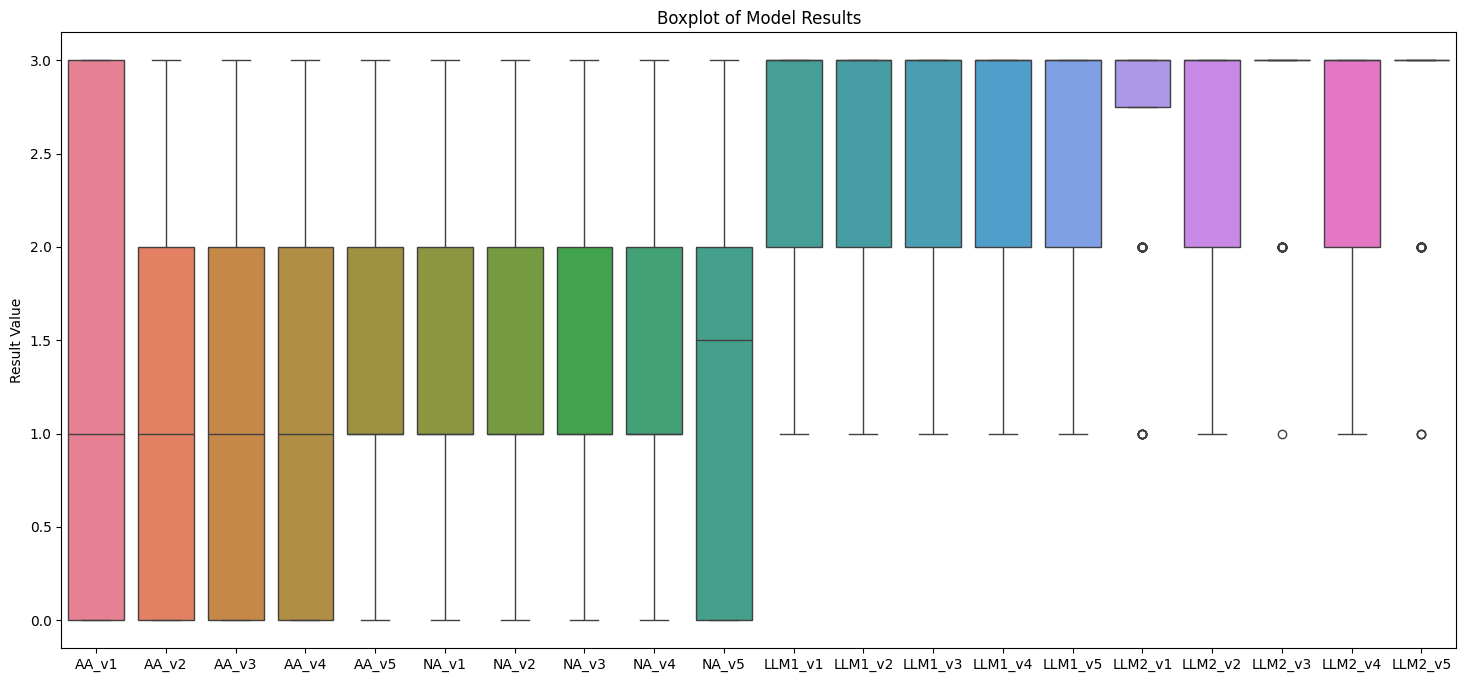

In [49]:

# Boxplot to visualize the spread and outliers
plt.figure(figsize=(18, 8))
sns.boxplot(data=results.drop(columns = columns_to_drop))
plt.title('Boxplot of Model Results')
plt.ylabel('Result Value')
plt.savefig("result_value.png", dpi=300, bbox_inches='tight')
plt.show()  

In [50]:

# Summary statistics
summary_stats = results.describe()
summary_stats.T.round(3)

,count,mean,std,min,25%,50%,75%,max
question,200.0,5.500,2.879,1.0,3.00,5.5,8.0,10.0
AA_v1,200.0,1.430,1.234,0.0,0.00,1.0,3.0,3.0
AA_v2,200.0,1.360,1.098,0.0,0.00,1.0,2.0,3.0
AA_v3,160.0,1.256,1.100,0.0,0.00,1.0,2.0,3.0
AA_v4,160.0,1.338,1.138,0.0,0.00,1.0,2.0,3.0
AA_v5,160.0,1.444,1.062,0.0,1.00,1.0,2.0,3.0
NA_v1,200.0,1.520,0.946,0.0,1.00,1.0,2.0,3.0
NA_v2,200.0,1.270,0.837,0.0,1.00,1.0,2.0,3.0
NA_v3,160.0,1.269,0.895,0.0,1.00,1.0,2.0,3.0
NA_v4,160.0,1.400,1.023,0.0,1.00,1.0,2.0,3.0


In [51]:
agg = aggregate_groups(results, agg="median")
agg

,model,project,question,AA,NA,LLM1,LLM2
key,,,,,,,
deepseek-r1_US285851_Q28,deepseek-r1,US285851,4,0.0,1.0,3.0,2.5
deepseek-r1_US285851_Q29,deepseek-r1,US285851,5,0.5,1.0,2.0,2.0
deepseek-r1_US285851_Q30,deepseek-r1,US285851,2,0.0,0.5,3.0,2.5
deepseek-r1_US285851_Q31,deepseek-r1,US285851,6,1.5,1.5,2.0,2.5
deepseek-r1_US285851_Q32,deepseek-r1,US285851,1,1.5,1.0,2.0,1.5
...,...,...,...,...,...,...,...
qwen3_US37581_Q23,qwen3,US37581,8,2.0,2.0,3.0,3.0
qwen3_US37581_Q24,qwen3,US37581,3,0.0,1.0,3.0,3.0
qwen3_US37581_Q25,qwen3,US37581,10,2.0,2.0,3.0,3.0


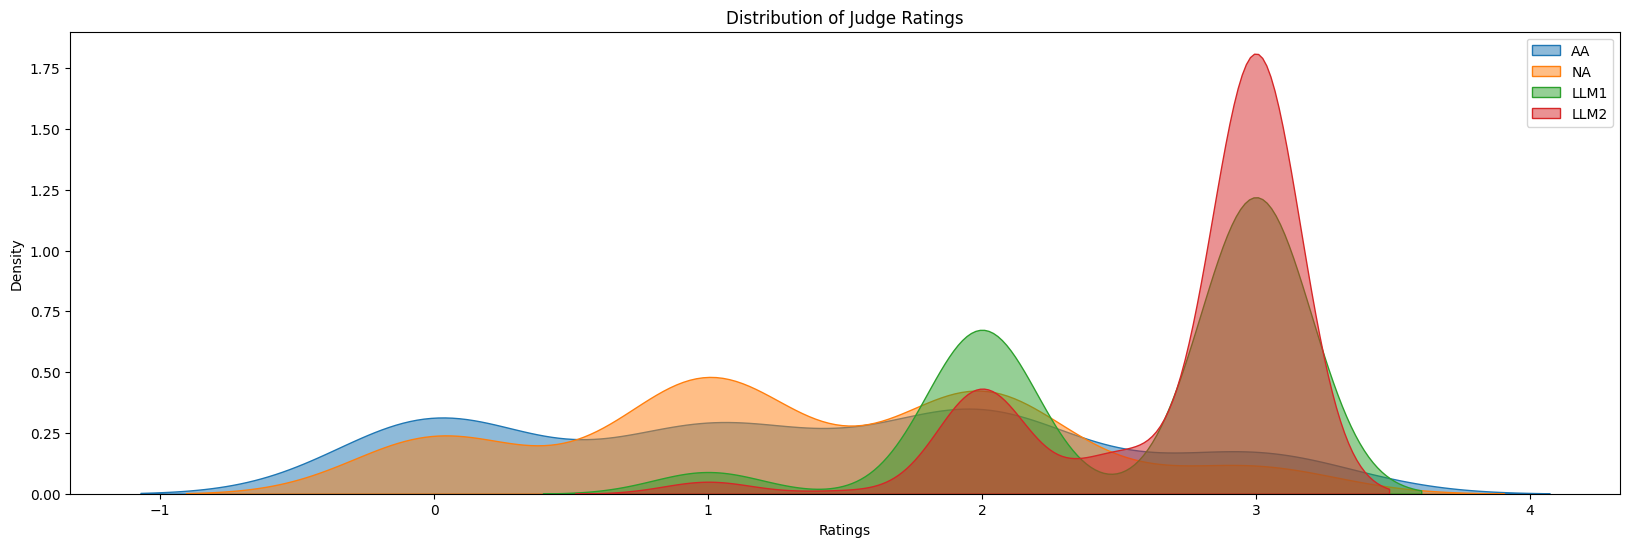

In [52]:
# Plot the distribution of results for each model
plt.figure(figsize=(20, 6))
for column in agg.drop(columns=columns_to_drop).columns:
    sns.kdeplot(agg[column], label=column, fill=True, alpha=0.5)
plt.title('Distribution of Judge Ratings')
plt.xlabel('Ratings')
plt.ylabel('Density')
plt.legend()
plt.savefig("judges_results_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [53]:
ci_results_boot = {}
for judge in agg.drop(columns=columns_to_drop).columns:
    lower, mean, upper = bootstrap_ci(agg[judge])
    ci_results_boot[judge] = {'lower': lower, 'mean': mean, 'upper': upper}

ci_df_boot = pd.DataFrame(ci_results_boot).T

In [54]:
ci_df_boot.round(3)

,lower,mean,upper
AA,1.192,1.335,1.480
NA,1.202,1.335,1.458
LLM1,2.485,2.570,2.650
LLM2,2.672,2.745,2.808


In [55]:
agg.corr = agg.drop(columns=columns_to_drop).corr('spearman').round(3)
agg.corr

,AA,NA,LLM1,LLM2
AA,1.000,0.741,0.204,0.172
NA,0.741,1.000,0.290,0.197
LLM1,0.204,0.290,1.000,0.490
LLM2,0.172,0.197,0.490,1.000


In [56]:
agg.mode = aggregate_groups(results, agg="mode")
agg.mode

,model,project,question,AA,NA,LLM1,LLM2
key,,,,,,,
deepseek-r1_US285851_Q28,deepseek-r1,US285851,4,0.0,1.0,3.0,3.0
deepseek-r1_US285851_Q29,deepseek-r1,US285851,5,0.0,1.0,2.0,1.0
deepseek-r1_US285851_Q30,deepseek-r1,US285851,2,0.0,0.0,3.0,3.0
deepseek-r1_US285851_Q31,deepseek-r1,US285851,6,1.0,1.0,2.0,2.0
deepseek-r1_US285851_Q32,deepseek-r1,US285851,1,3.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...
qwen3_US37581_Q23,qwen3,US37581,8,1.0,2.0,3.0,3.0
qwen3_US37581_Q24,qwen3,US37581,3,0.0,1.0,3.0,3.0
qwen3_US37581_Q25,qwen3,US37581,10,2.0,2.0,3.0,3.0


In [57]:
agg.corr.mode = agg.mode.drop(columns=columns_to_drop).corr('spearman').round(3)
agg.corr.mode

,AA,NA,LLM1,LLM2
AA,1.000,0.743,0.201,0.173
NA,0.743,1.000,0.263,0.187
LLM1,0.201,0.263,1.000,0.551
LLM2,0.173,0.187,0.551,1.000


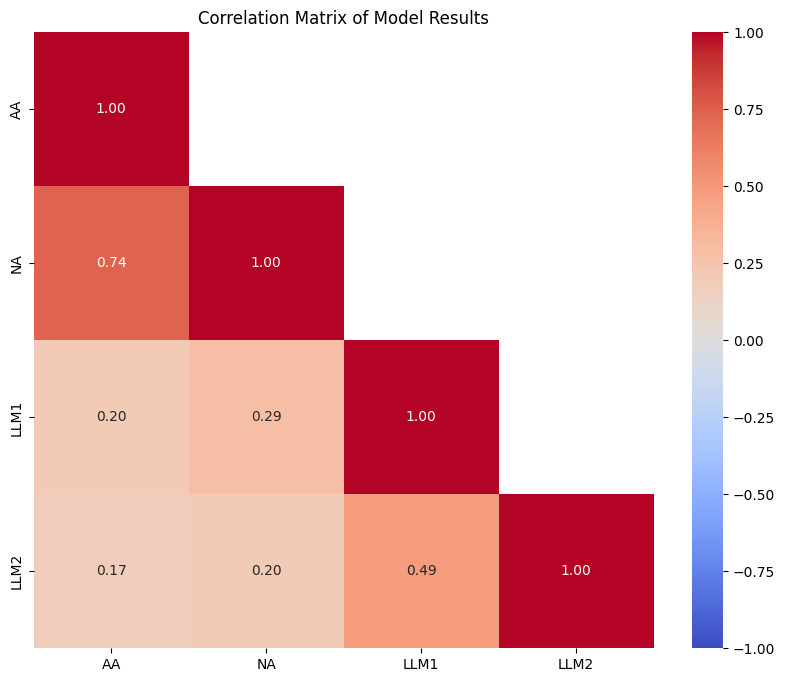

In [58]:
# Generate a heatmap

# Create a mask for the diagonal
#mask = np.eye(corr.shape[0], dtype=bool)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(agg.corr, dtype=bool), k=1)  # lower triangle is True, upper is False

plt.figure(figsize=(10, 8))
sns.heatmap(agg.corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, mask=mask)
plt.title('Correlation Matrix of Model Results')
plt.savefig("model_results_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.savefig("model_results_correlation_matrix.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show() 

## Weighted Cohen Kappa & Spearman (judges < 3) & Kendall W & Krippendorff Alpha (judges > 2)

In [59]:
llm_judges = ["LLM1","LLM2"]
professional_judges = ["AA","NA"]

## Concordance between the 2 professionals (Project Managers)

In [60]:

q_results = concordance_computation( agg, mode="question", columns_to_exclude = columns_to_drop + llm_judges , ndigits=3)
m_results = concordance_computation( agg, mode="model", columns_to_exclude = columns_to_drop + llm_judges, ndigits=3)
p_results = concordance_computation( agg, mode="project", columns_to_exclude = columns_to_drop + llm_judges, ndigits=3)
plot_dataframes_side_by_side( [q_results, m_results, p_results], ["Per Question Concordance", "Per Model Concordance", "Per Project Concordance"] )

,Id,Cohen_kappa,Kendall_W,Spearman,Krippendorff_alpha,AA_median,AA_mode,NA_median,NA_mode
0,1,0.688000,0.816000,0.769000,0.678000,2.000000,3.000000,1.750000,2.000000
1,2,0.613000,0.459000,0.543000,0.368000,0.000000,0.000000,0.250000,0.000000
2,3,0.799000,0.733000,0.714000,0.643000,0.000000,0.000000,0.750000,0.000000
3,4,0.744000,0.807000,0.822000,0.747000,2.000000,3.000000,2.000000,2.000000
4,5,0.450000,0.571000,0.584000,0.434000,0.000000,0.000000,1.000000,1.000000
5,6,0.298000,0.552000,0.269000,0.264000,1.000000,1.000000,1.000000,1.000000
6,7,0.244000,0.548000,0.250000,0.246000,2.000000,2.000000,2.000000,2.000000
7,8,0.295000,0.581000,0.361000,0.372000,2.000000,2.000000,2.000000,1.000000
8,9,0.808000,0.793000,0.727000,0.729000,1.250000,1.000000,1.750000,2.000000
9,10,0.200000,0.491000,0.208000,0.236000,2.000000,2.000000,2.000000,2.000000


In [61]:
q_results.to_latex("concordance_per_question_AA_NA.tex", caption="Per Question Concordance (AA & NA Judges)", label="tab:per_question_concordance_AA_NA_judges", float_format="%.3f", index=False)
m_results.to_latex("concordance_per_model_AA_NA.tex", caption="Per Model Concordance (AA & NA Judges)", label="tab:per_model_concordance_AA_NA_judges", float_format="%.3f", index=False)
p_results.to_latex("concordance_per_project_AA_NA.tex", caption="Per Project Concordance (AA & NA Judges)", label="tab:per_project_concordance_AA_NA_judges", float_format="%.3f", index=False)

In [62]:
#!pip install -U Kaleido
#plot_metrics( q_results, njudges=2, filename="inter-rater agreement metrics per ID.pdf")
plot_metrics( q_results, njudges=2)

In [63]:
plot_metrics( m_results, njudges=2 )

In [64]:
plot_metrics( p_results, njudges=2 )

## Concordance between the 2 LLMs

In [112]:
q_results = concordance_computation( agg, mode="question", columns_to_exclude = columns_to_drop + professional_judges , ndigits=3)
m_results = concordance_computation( agg, mode="model", columns_to_exclude = columns_to_drop + professional_judges, ndigits=3)
p_results = concordance_computation( agg, mode="project", columns_to_exclude = columns_to_drop + professional_judges, ndigits=3)
plot_dataframes_side_by_side( [q_results, m_results, p_results], ["Per Question Concordance", "Per Model Concordance", "Per Project Concordance"] )
q_results.to_latex("concordance_per_question_2xLLM.tex", caption="Per Question Concordance (LLM1 & LLM2 Judges)", label="tab:per_question_concordance_LLM_judges", float_format="%.3f", index=False)

,Id,Cohen_kappa,Kendall_W,Spearman,Krippendorff_alpha,LLM1_median,LLM1_mode,LLM2_median,LLM2_mode
0,1,0.636000,0.682000,0.615000,0.618000,2.000000,2.000000,2.000000,2.000000
1,2,-0.023000,0.416000,0.170000,0.189000,2.000000,2.000000,2.000000,2.000000
2,3,0.625000,0.674000,0.666000,0.602000,2.000000,2.000000,3.000000,3.000000
3,4,-0.100000,0.351000,-0.041000,-0.034000,2.500000,2.000000,3.000000,3.000000
4,5,0.516000,0.576000,0.567000,0.491000,2.000000,2.000000,3.000000,3.000000
5,6,0.118000,0.395000,0.242000,-0.080000,2.000000,2.000000,3.000000,3.000000
6,7,0.000000,0.036000,nan,0.000000,3.000000,3.000000,3.000000,3.000000
7,8,nan,0.000000,nan,1.000000,3.000000,3.000000,3.000000,3.000000
8,9,-0.154000,0.158000,-0.167000,-0.146000,3.000000,3.000000,3.000000,3.000000
9,10,nan,0.000000,nan,1.000000,3.000000,3.000000,3.000000,3.000000


In [66]:
plot_metrics( q_results, njudges=2 )
#plot_metrics( q_results, njudges=2, filename="inter-rater agreement metrics per ID_LLMs.pdf")

In [67]:
plot_metrics( m_results, njudges=2 )

In [68]:
plot_metrics( p_results, njudges=2 )

## Concordance between AA and LLM1

In [69]:
q_results = concordance_computation( agg, mode="question", columns_to_exclude = columns_to_drop + [professional_judges[1]] + [llm_judges[1]] , ndigits=3)
m_results = concordance_computation( agg, mode="model", columns_to_exclude = columns_to_drop + [professional_judges[1]] + [llm_judges[1]] , ndigits=3)
p_results = concordance_computation( agg, mode="project", columns_to_exclude = columns_to_drop + [professional_judges[1]] + [llm_judges[1]] , ndigits=3)
plot_dataframes_side_by_side( [q_results, m_results, p_results], ["Per Question Concordance", "Per Model Concordance", "Per Project Concordance"] )

,Id,Cohen_kappa,Kendall_W,Spearman,Krippendorff_alpha,AA_median,AA_mode,LLM1_median,LLM1_mode
0,1,-0.096000,0.402000,-0.086000,-0.048000,2.000000,3.000000,2.000000,2.000000
1,2,-0.031000,0.187000,-0.274000,-0.809000,0.000000,0.000000,2.000000,2.000000
2,3,-0.021000,0.377000,-0.054000,-0.411000,0.000000,0.000000,2.000000,2.000000
3,4,-0.026000,0.381000,-0.090000,-0.153000,2.000000,3.000000,2.500000,2.000000
4,5,0.033000,0.464000,0.189000,-0.646000,0.000000,0.000000,2.000000,2.000000
5,6,0.079000,0.440000,0.053000,-0.265000,1.000000,1.000000,2.000000,2.000000
6,7,-0.015000,0.221000,-0.151000,-0.663000,2.000000,2.000000,3.000000,3.000000
7,8,0.000000,0.208000,nan,-0.766000,2.000000,2.000000,3.000000,3.000000
8,9,0.120000,0.508000,0.475000,-0.344000,1.250000,1.000000,3.000000,3.000000
9,10,0.000000,0.202000,nan,-0.484000,2.000000,2.000000,3.000000,3.000000


In [70]:
plot_metrics( q_results, njudges=2 )

In [71]:
plot_metrics( m_results, njudges=2 )

In [72]:
plot_metrics( p_results, njudges=2 )

## Concordance between NA and LLM1

In [114]:
q_results = concordance_computation( agg, mode="question", columns_to_exclude = columns_to_drop + [professional_judges[0]] + [llm_judges[1]] , ndigits=3)
m_results = concordance_computation( agg, mode="model", columns_to_exclude = columns_to_drop + [professional_judges[0]] + [llm_judges[1]] , ndigits=3)
p_results = concordance_computation( agg, mode="project", columns_to_exclude = columns_to_drop + [professional_judges[0]] + [llm_judges[1]] , ndigits=3)
plot_dataframes_side_by_side( [q_results, m_results, p_results], ["Per Question Concordance", "Per Model Concordance", "Per Project Concordance"] )
q_results.to_latex("concordance_per_question_NA_LLM1.tex", caption="Per Question Concordance (NA & LLM1 Judges)", label="tab:per_question_concordance_NA_LLM1_judges", float_format="%.3f", index=False)

,Id,Cohen_kappa,Kendall_W,Spearman,Krippendorff_alpha,NA_median,NA_mode,LLM1_median,LLM1_mode
0,1,-0.075000,0.383000,-0.137000,-0.160000,1.750000,2.000000,2.000000,2.000000
1,2,-0.018000,0.389000,0.062000,-0.747000,0.250000,0.000000,2.000000,2.000000
2,3,-0.034000,0.335000,-0.233000,-0.574000,0.750000,0.000000,2.000000,2.000000
3,4,0.071000,0.468000,0.169000,-0.190000,2.000000,2.000000,2.500000,2.000000
4,5,-0.016000,0.351000,-0.076000,-0.705000,1.000000,1.000000,2.000000,2.000000
5,6,0.068000,0.497000,0.204000,-0.366000,1.000000,1.000000,2.000000,2.000000
6,7,-0.009000,0.255000,-0.042000,-0.562000,2.000000,2.000000,3.000000,3.000000
7,8,0.000000,0.218000,nan,-0.761000,2.000000,1.000000,3.000000,3.000000
8,9,0.123000,0.470000,0.362000,-0.370000,1.750000,2.000000,3.000000,3.000000
9,10,0.000000,0.205000,nan,-0.535000,2.000000,2.000000,3.000000,3.000000


In [74]:
plot_metrics( q_results, njudges=2 )

In [75]:
plot_metrics( m_results, njudges=2 )

In [76]:
plot_metrics( p_results, njudges=2 )

## Concordance between AA and LLM2

In [77]:
q_results = concordance_computation( agg, mode="question", columns_to_exclude = columns_to_drop + [professional_judges[1]] + [llm_judges[0]] , ndigits=3)
m_results = concordance_computation( agg, mode="model", columns_to_exclude = columns_to_drop + [professional_judges[1]] + [llm_judges[0]] , ndigits=3)
p_results = concordance_computation( agg, mode="project", columns_to_exclude = columns_to_drop + [professional_judges[1]] + [llm_judges[0]] , ndigits=3)
plot_dataframes_side_by_side( [q_results, m_results, p_results], ["Per Question Concordance", "Per Model Concordance", "Per Project Concordance"] )

,Id,Cohen_kappa,Kendall_W,Spearman,Krippendorff_alpha,AA_median,AA_mode,LLM2_median,LLM2_mode
0,1,-0.095000,0.451000,0.026000,0.061000,2.000000,3.000000,2.000000,2.000000
1,2,-0.035000,0.193000,-0.367000,-0.820000,0.000000,0.000000,2.000000,2.000000
2,3,0.031000,0.401000,0.009000,-0.412000,0.000000,0.000000,3.000000,3.000000
3,4,0.189000,0.564000,0.385000,0.123000,2.000000,3.000000,3.000000,3.000000
4,5,-0.021000,0.239000,-0.318000,-0.783000,0.000000,0.000000,3.000000,3.000000
5,6,-0.060000,0.295000,-0.141000,-0.724000,1.000000,1.000000,3.000000,3.000000
6,7,0.000000,0.211000,nan,-0.702000,2.000000,2.000000,3.000000,3.000000
7,8,0.000000,0.208000,nan,-0.766000,2.000000,2.000000,3.000000,3.000000
8,9,-0.037000,0.256000,-0.166000,-0.653000,1.250000,1.000000,3.000000,3.000000
9,10,0.000000,0.202000,nan,-0.484000,2.000000,2.000000,3.000000,3.000000


In [78]:
plot_metrics( q_results, njudges=2 )

In [79]:
plot_metrics( q_results, njudges=2 )

In [80]:
plot_metrics( q_results, njudges=2 )

## Concordance between NA and LLM2

In [81]:
q_results = concordance_computation( agg, mode="question", columns_to_exclude = columns_to_drop + [professional_judges[0]] + [llm_judges[0]] , ndigits=3)
m_results = concordance_computation( agg, mode="model", columns_to_exclude = columns_to_drop + [professional_judges[0]] + [llm_judges[0]] , ndigits=3)
p_results = concordance_computation( agg, mode="project", columns_to_exclude = columns_to_drop + [professional_judges[0]] + [llm_judges[0]] , ndigits=3)
plot_dataframes_side_by_side( [q_results, m_results, p_results], ["Per Question Concordance", "Per Model Concordance", "Per Project Concordance"] )

,Id,Cohen_kappa,Kendall_W,Spearman,Krippendorff_alpha,NA_median,NA_mode,LLM2_median,LLM2_mode
0,1,-0.025000,0.452000,0.016000,-0.126000,1.750000,2.000000,2.000000,2.000000
1,2,-0.051000,0.213000,-0.475000,-0.841000,0.250000,0.000000,2.000000,2.000000
2,3,0.024000,0.360000,-0.173000,-0.629000,0.750000,0.000000,3.000000,3.000000
3,4,0.177000,0.557000,0.430000,-0.225000,2.000000,2.000000,3.000000,3.000000
4,5,-0.040000,0.220000,-0.350000,-0.775000,1.000000,1.000000,3.000000,3.000000
5,6,-0.045000,0.259000,-0.238000,-0.797000,1.000000,1.000000,3.000000,3.000000
6,7,0.000000,0.227000,nan,-0.637000,2.000000,2.000000,3.000000,3.000000
7,8,0.000000,0.218000,nan,-0.761000,2.000000,1.000000,3.000000,3.000000
8,9,-0.031000,0.278000,-0.075000,-0.647000,1.750000,2.000000,3.000000,3.000000
9,10,0.000000,0.205000,nan,-0.535000,2.000000,2.000000,3.000000,3.000000


In [108]:
plot_metrics( q_results, njudges=3 )

In [83]:
plot_metrics( m_results, njudges=2 )

In [84]:
plot_metrics( p_results, njudges=2 )

In [85]:
from sklearn.metrics import cohen_kappa_score

# Example: agreement between AA_total and NA_total
kappa = cohen_kappa_score(agg.query("question==10")["AA"].round().astype(int), agg.query("question==10")["NA"].round().astype(int), weights="quadratic")
print("Cohen’s Kappa:", kappa)

Cohen’s Kappa: 0.19999999999999996


In [86]:
from sklearn.metrics import cohen_kappa_score

# Example: agreement between AA_total and NA_total
kappa = cohen_kappa_score(agg.query("question==1")["AA"].round().astype(int), agg.query("question==1")["LLM1"].round().astype(int), weights="quadratic")
print("Cohen’s Kappa:", kappa)

Cohen’s Kappa: -0.09589041095890405


In [87]:
from sklearn.metrics import cohen_kappa_score

# Example: agreement between AA_total and NA_total
kappa = cohen_kappa_score(agg.query("question==1")["NA"].round().astype(int), agg.query("question==1")["LLM1"].round().astype(int), weights="quadratic")
print("Cohen’s Kappa:", kappa)

Cohen’s Kappa: -0.07499999999999996


In [88]:
agg.query("question==1")[["AA", "LLM2"]]

,AA,LLM2
key,,
deepseek-r1_US285851_Q32,1.5,1.5
deepseek-r1_US293949_Q42,1.5,3.0
deepseek-r1_US37581_285851_293949_Q52,3.0,2.5
deepseek-r1_US37581_Q22,0.0,2.0
gpt-3.5-turbo_US285851_Q32,2.0,2.0
gpt-3.5-turbo_US293949_Q42,2.0,2.0
gpt-3.5-turbo_US37581_285851_293949_Q52,3.0,3.0
gpt-3.5-turbo_US37581_Q22,3.0,2.0
gpt-4o_US285851_Q32,3.0,3.0


## Concordance between all (Professionals + LLMs)

In [89]:
#llm_judge = ['LLM_v1','LLM_v2','LLM_v3','LLM_v4','LLM_v5']

q_results = concordance_computation( agg, mode="question", columns_to_exclude = columns_to_drop, ndigits=3)
m_results = concordance_computation( agg, mode="model", columns_to_exclude = columns_to_drop, ndigits=3)
p_results = concordance_computation( agg, mode="project", columns_to_exclude = columns_to_drop, ndigits=3)
plot_dataframes_side_by_side( [q_results, m_results, p_results], ["Per Question Concordance", "Per Model Concordance", "Per Project Concordance"] )

,Id,Kendall_W,Krippendorff_alpha,AA_median,AA_mode,NA_median,NA_mode,LLM1_median,LLM1_mode,LLM2_median,LLM2_mode
0,1,0.355000,0.179000,2.000000,3.000000,1.750000,2.000000,2.000000,2.000000,2.000000,2.000000
1,2,0.134000,-0.260000,0.000000,0.000000,0.250000,0.000000,2.000000,2.000000,2.000000,2.000000
2,3,0.303000,-0.066000,0.000000,0.000000,0.750000,0.000000,2.000000,2.000000,3.000000,3.000000
3,4,0.378000,0.106000,2.000000,3.000000,2.000000,2.000000,2.500000,2.000000,3.000000,3.000000
4,5,0.241000,-0.206000,0.000000,0.000000,1.000000,1.000000,2.000000,2.000000,3.000000,3.000000
5,6,0.232000,-0.155000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,3.000000,3.000000
6,7,0.137000,-0.186000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000
7,8,0.145000,-0.247000,2.000000,2.000000,2.000000,1.000000,3.000000,3.000000,3.000000,3.000000
8,9,0.292000,-0.067000,1.250000,1.000000,1.750000,2.000000,3.000000,3.000000,3.000000,3.000000
9,10,0.123000,-0.121000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000


In [90]:
plot_metrics( q_results, njudges=3 )

In [91]:
plot_metrics( m_results, njudges=3 )

In [100]:
plot_metrics( p_results, njudges=3 )

### Export any Dataframe to Latex

In [93]:
# Export a dataframe to Latex with only 3 decimal spaces
# Upload the file "concordance_per_question_all.tex" to your project and use it like:     \input{concordance_per_question_all.tex}
# Reference the table in your text like:     \ref{tab:per_question_concordance_all_judges}
# Repeat for any other dataframe/table you want to export to Latex
q_results.to_latex("concordance_per_question_all.tex", caption="Per Question Concordance (All Judges)", label="tab:per_question_concordance_all_judges", float_format="%.3f", index=False)

In [94]:
import nbformat
from nbconvert import LatexExporter

# Load the notebook
notebook_filename = "AI-Evaluation-New.ipynb"
with open(notebook_filename, 'r', encoding='utf-8') as f:
    notebook_node = nbformat.read(f, as_version=4)

# Create the exporter, removing the code cells from output
latex_exporter = LatexExporter()
latex_exporter.exclude_input = True       # No code cells in export
latex_exporter.exclude_input_prompt = True # No In[...] prompts

# Export to LaTeX
body, resources = latex_exporter.from_notebook_node(notebook_node)

with open("AI-Evaluation-New.tex", "w", encoding='utf-8') as f:
    f.write(body)


c:\Python\share\jupyter\nbconvert\templates\latex\display_priority.j2:32: UserWarning:

Your element with mimetype(s) dict_keys(['application/vnd.plotly.v1+json']) is not able to be represented.

